# SI — Model selection and validation

Produces `figures/fig_SI3.pdf` and the two LaTeX tables
`tables/table_intrinsic_fits.tex` and `tables/table_branching_fits.tex`.

Compares the candidate intrinsic-time laws for `D(t)` — linear, `t/log t`,
power law — and the candidate branching laws for `D_w(D)` — linear,
logarithmic, power law, exponential — selecting on linear RMSE.

Requires the trajectory cache built by `module_3_trajectories.ipynb`.


In [1]:
# Repository bootstrap.
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "lib").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / "lib") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "lib"))

OUTPUT_DIR = REPO_ROOT / "outputs"               # derived data, auto-generated
FIGURE_DIR = REPO_ROOT / "figures"               # manuscript figures, versioned
TABLE_DIR = REPO_ROOT / "tables"                 # manuscript tables, versioned
TRAJECTORY_DIR = OUTPUT_DIR / "trajectories"     # built by module_3_trajectories

# Papers without keywords cannot produce a combination novelty and are excluded
# from the event process. This is the convention of the revised manuscript.
filter_empty_keywords = True


## Imports and style


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plot_style import apply_si_style, DIST_COLORS, SI_DATA_LW, SI_FIT_LW, SI_REF_LW

apply_si_style()
colors_dist = dict(DIST_COLORS)

pd.set_option("display.max_columns", 60)


## Load the trajectories

The event-level trajectory, plus a version compressed to one row per calendar
day (`daily`) for the natural-time panels.


In [3]:
from utils import (
    block_b_summary,
    branching_models,
    compress_by_date,
    display_stride,
    fit_exponential_vs_tau,
    fit_intrinsic_models,
    load_all_trajectories,
)

trajectories = load_all_trajectories(
    TRAJECTORY_DIR,
    filter_empty_keywords=filter_empty_keywords,
)
daily = {name: compress_by_date(traj) for name, traj in trajectories.items()}

for name, traj in trajectories.items():
    print(name, traj.n)


patents 1431653
papers 5193236


## The figure and the fit tables

3×2 figure. Row 1: the two intrinsic-time diagnostics — `D(t) log t / t`,
which flattens to a constant if `D` grows like `t/log t`, and the local
exponent `d log D / d log t`, which approaches 1. Row 2: the natural-time
exponential growth of `D`, `D_w` and `t`, whose common slope is `ab`. Row 3:
the branching relation and the stability of the local slope `b` over time.

The same cell writes the two LaTeX tables of fitted parameters and RMSEs that
the SI includes with `\input`.


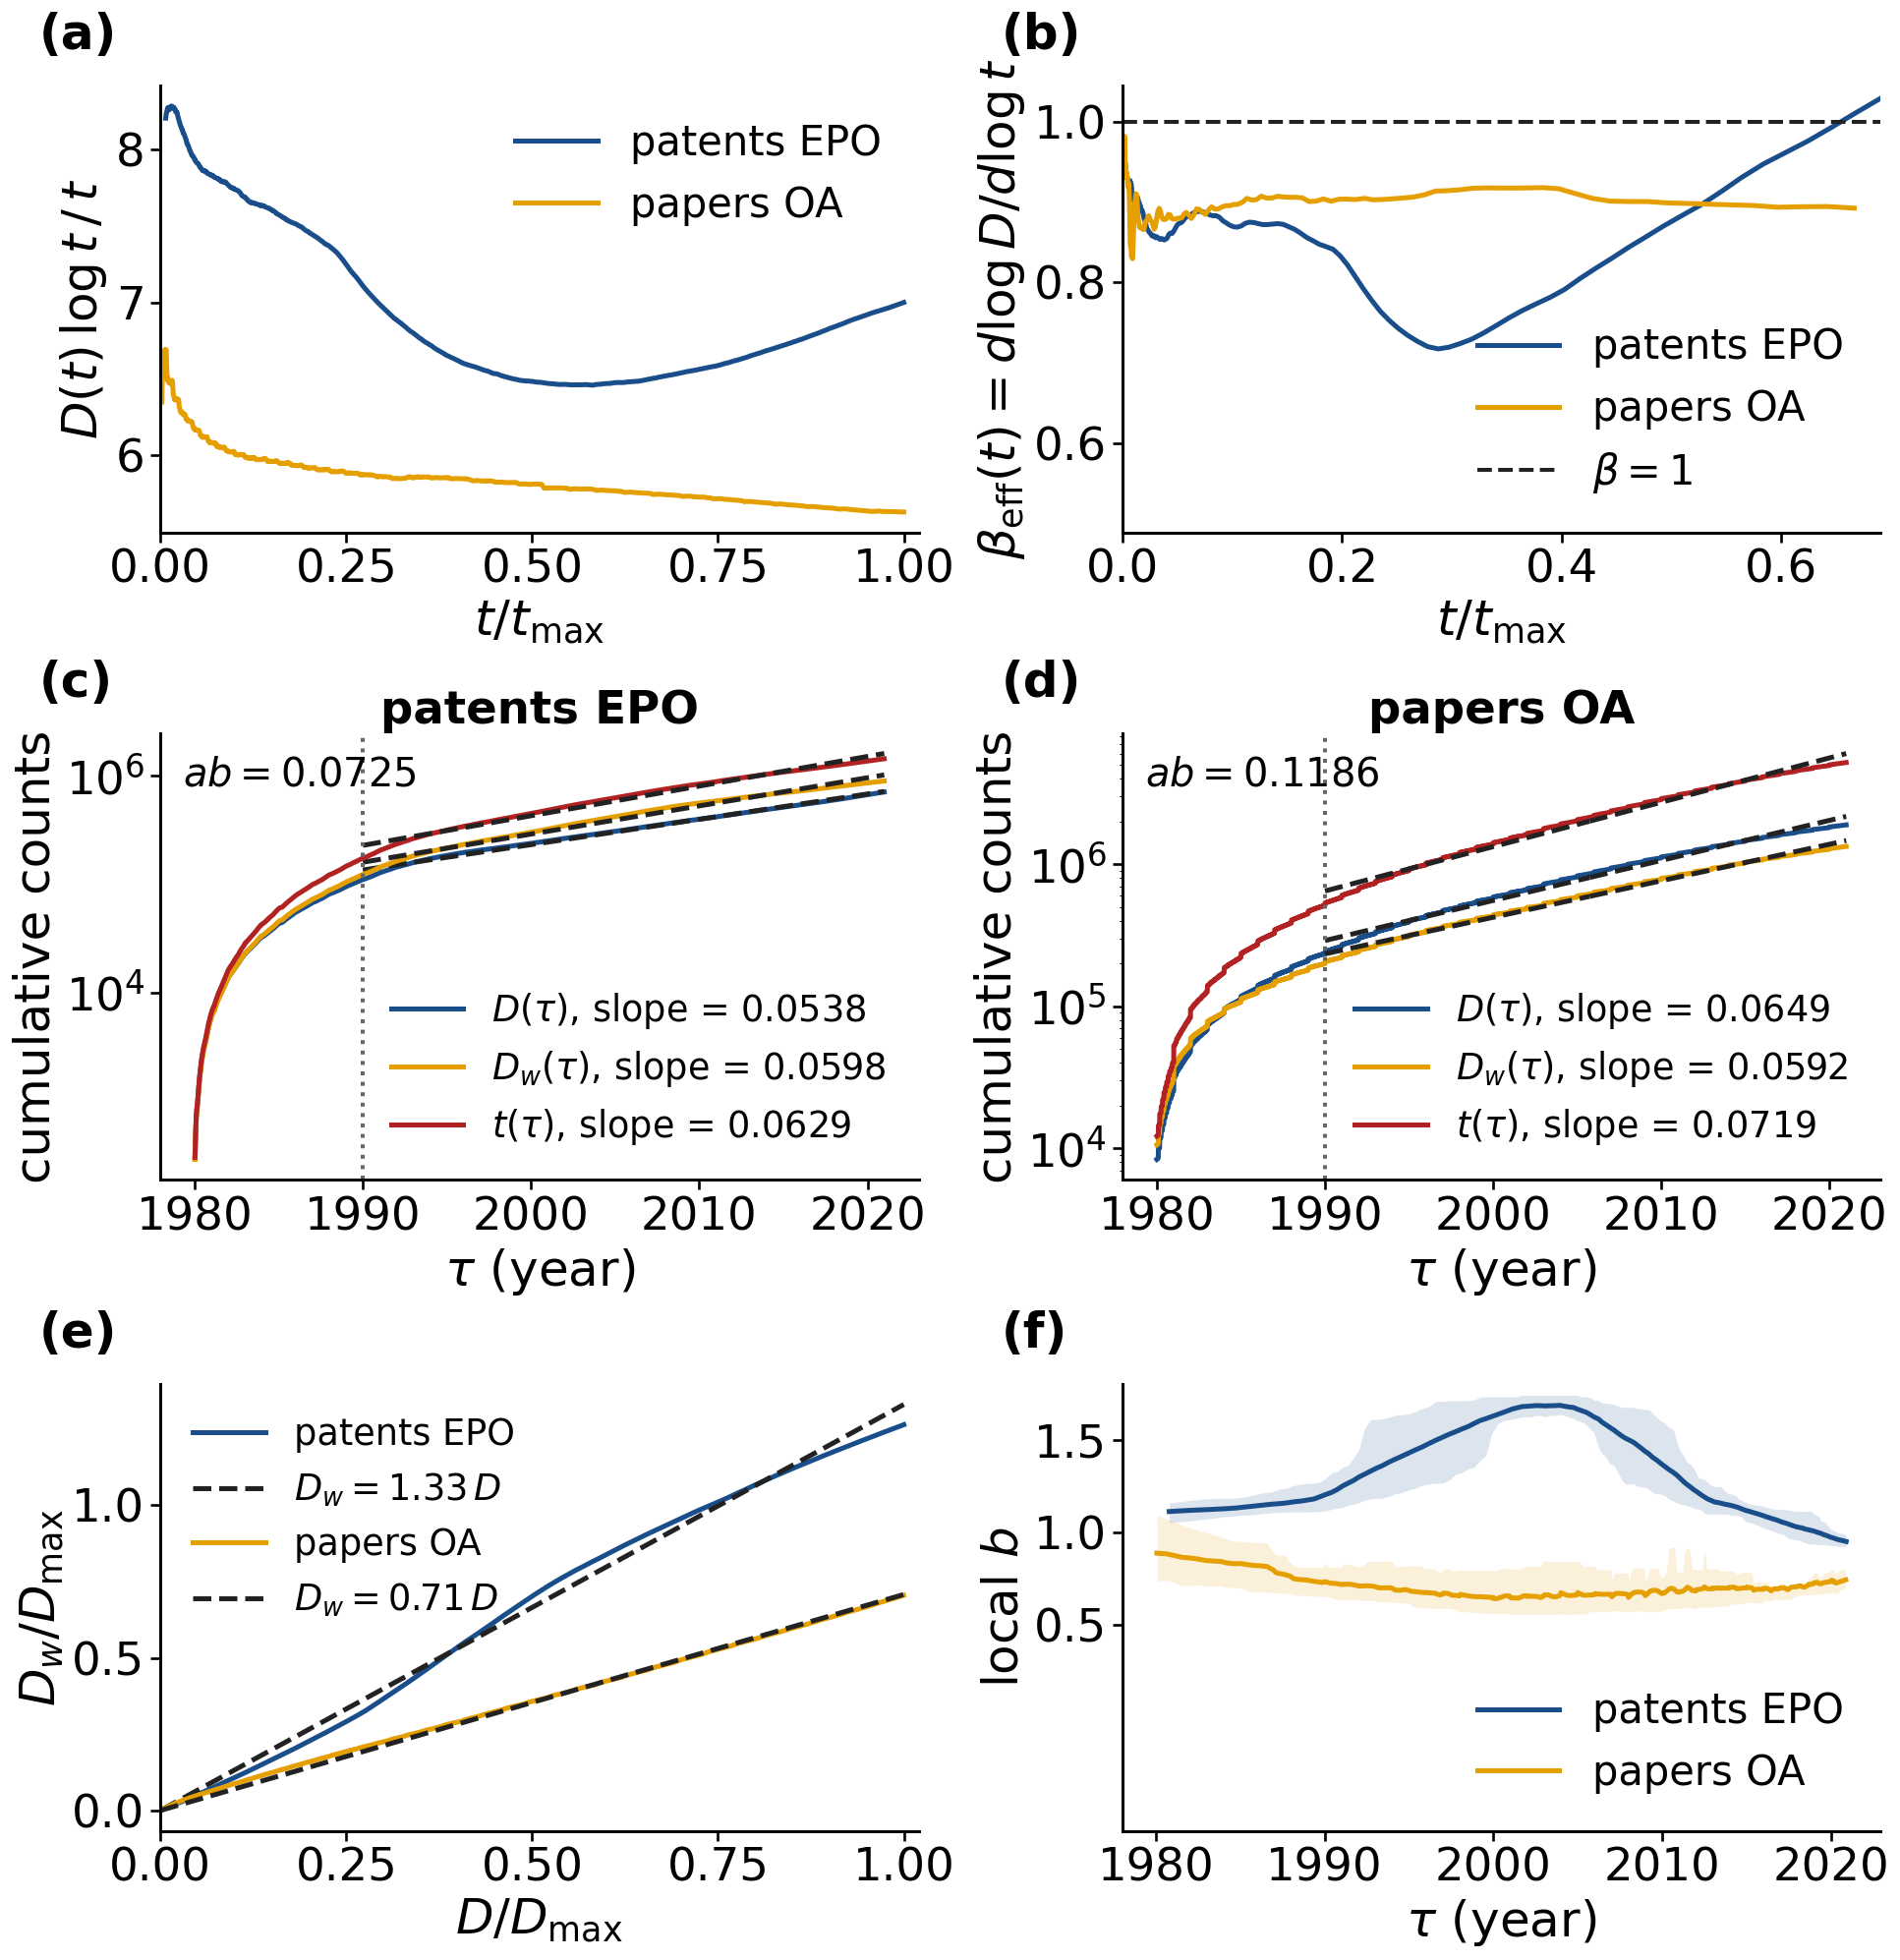

figure -> figures/fig_SI3.pdf
('patents', 'D') 0.0538
('patents', 'Dw') 0.0598
('patents', 't') 0.0629
('papers', 'D') 0.0649
('papers', 'Dw') 0.0592
('papers', 't') 0.0719


\begin{tabular}{lccr}
\toprule
Model & $a$ & $\beta$ & RMSE \\
\midrule
\multicolumn{4}{l}{\textit{patents EPO}} \\
marginal, $D=a\,t/\log t$ & $6.71251 \pm 0.00017$ & -- & $1.245\times 10^{4}$ \\
linear, $D=a\,t$ & $0.485278 \pm 0.000016$ & -- & $1.590\times 10^{4}$ \\
power law, $D=a\,t^{\beta}$ & $3.2527 \pm 0.0014$ & $0.861760 \pm 0.000032$ & $1.609\times 10^{4}$ \\
\midrule
\multicolumn{4}{l}{\textit{papers OA}} \\
marginal, $D=a\,t/\log t$ & $5.716667 \pm 0.000033$ & -- & $1.470\times 10^{4}$ \\
linear, $D=a\,t$ & $0.377930 \pm 0.000006$ & -- & $4.064\times 10^{4}$ \\
power law, $D=a\,t^{\beta}$ & $1.746508 \pm 0.000085$ & $0.898779 \pm 0.000003$ & $3.254\times 10^{3}$ \\
\bottomrule
\end{tabular}

\begin{tabular}{lcccr}
\toprule
Model & $a$ & $b$ & $\beta$ & RMSE \\
\midrule
\multicolumn{5}{l}{\textit{patents EPO}} \\
linear, $D_w=b\,D$ & -- & $1.330502 \pm 0.000045$ & -- & $2.175\times 10^{4}$ \\
power law, $D_w=a\,D^{\beta}$ & $0.40786 \pm 0.00025$ & -- & $1.091065 \pm 0.00004

In [4]:
# Final SI figure and tables for the "Model selection and validation" section.
# One 3x2 figure (intrinsic time / natural time / branching) plus two LaTeX
# tables, exported as vector PDF into figures/ and tables/.
import math

from plot_style import OBSERVABLE_COLORS
from utils import beta_eff_binned

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['patents', 'papers']
DATASET_LABEL = {'patents': 'patents EPO', 'papers': 'papers OA'}
DATASET_COLOR = {'patents': colors_dist['patents'], 'papers': colors_dist['papers']}
REFERENCE_COLOR = colors_dist['reference']

# Manuscript calibration (post keyword-filter values, see Methods).
MODEL_AB_FINAL = {
    'patents': {'a': 0.0545, 'b': 1.33},
    'papers': {'a': 0.167, 'b': 0.71},
}
TAU_FIT_START_FINAL = 1990.0
# Burn-in for the intrinsic-time diagnostics: below 10^4 events the curves are
# dominated by the very first novelties and compress into a vertical spike.
BETA_T_MIN = 1.0e4
BLOCK_FINAL_FIG = {
    'patents': {'block_size': 10_000, 'smooth_blocks': 31},
    'papers': {'block_size': 20_000, 'smooth_blocks': 31},
}


def _panel_label(ax, text):
    ax.text(-0.16, 1.06, text, transform=ax.transAxes, va='bottom', ha='left',
            fontsize=30, fontweight='bold')


fig, axes = plt.subplots(3, 2, figsize=(16, 16.5), constrained_layout=True)

# --- row 1: intrinsic-time scaling diagnostics ------------------------------
ax = axes[0, 0]
for name in DATASETS:
    traj = trajectories[name]
    t_full = traj.t.astype(np.float64)
    D_full = np.asarray(traj.D, dtype=np.float64)
    keep = t_full >= BETA_T_MIN
    t_full, D_full = t_full[keep], D_full[keep]
    stride = display_stride(len(t_full), max_points=4000)
    ratio = D_full * np.log(t_full) / t_full
    ax.plot(t_full[::stride] / t_full.max(), ratio[::stride], lw=SI_DATA_LW,
            color=DATASET_COLOR[name], label=DATASET_LABEL[name])
ax.set_xlabel(r'$t/t_{\max}$')
ax.set_ylabel(r'$D(t)\,\log t\,/\,t$')
ax.set_xlim(0.0, 1.02)
ax.legend(loc='upper right', frameon=False)
_panel_label(ax, '(a)')

ax = axes[0, 1]
beta_x_max = 0.0
for name in DATASETS:
    traj = trajectories[name]
    t_bin, beta_bin = beta_eff_binned(
        traj.t.astype(np.float64), np.asarray(traj.D, dtype=np.float64),
        trim_windows=1, t_min=BETA_T_MIN,
    )
    x_rescaled = t_bin / traj.t.max()
    beta_x_max = max(beta_x_max, float(x_rescaled.max()))
    ax.plot(x_rescaled, beta_bin, lw=SI_DATA_LW,
            color=DATASET_COLOR[name], label=DATASET_LABEL[name])
ax.axhline(1.0, ls='--', lw=SI_REF_LW, color=REFERENCE_COLOR, label=r'$\beta=1$')
ax.set_xlabel(r'$t/t_{\max}$')
ax.set_ylabel(r'$\beta_{\mathrm{eff}}(t)=d\log D/d\log t$')
# The estimator is truncated at both ends, so the axis stops where the data do.
ax.set_xlim(0.0, beta_x_max)
# Headroom below the curves so the legend does not sit on the patent trace.
_ylo, _yhi = ax.get_ylim()
ax.set_ylim(bottom=_ylo - 0.62 * (_yhi - _ylo))
ax.legend(loc='lower right', frameon=False)
_panel_label(ax, '(b)')

# --- row 2: natural-time exponential scaling --------------------------------
NATURAL_SERIES = [
    ('D', r'$D(\tau)$', 'novelty'),
    ('Dw', r'$D_w(\tau)$', 'explorers'),
    ('t', r'$t(\tau)$', 'intrinsic_time'),
]
natural_slopes = {}
for col, name in enumerate(DATASETS):
    ax = axes[1, col]
    daily_df = daily[name]
    tau_vals = daily_df['tau'].to_numpy(dtype=float)
    ab_value = MODEL_AB_FINAL[name]['a'] * MODEL_AB_FINAL[name]['b']
    for key, tex, semantic in NATURAL_SERIES:
        y_vals = daily_df[key].to_numpy(dtype=float)
        fit_info = fit_exponential_vs_tau(tau_vals, y_vals, tau_min=TAU_FIT_START_FINAL)
        natural_slopes[(name, key)] = fit_info['slope']
        fit_mask = tau_vals >= TAU_FIT_START_FINAL
        ax.semilogy(tau_vals, np.maximum(y_vals, 1.0), lw=SI_DATA_LW,
                    color=OBSERVABLE_COLORS[semantic],
                    label='%s, slope = %.4f' % (tex, fit_info['slope']))
        ax.semilogy(tau_vals[fit_mask],
                    np.exp(fit_info['intercept'] + fit_info['slope'] * tau_vals[fit_mask]),
                    ls='--', lw=SI_FIT_LW, color=REFERENCE_COLOR)
    ax.axvline(TAU_FIT_START_FINAL, ls=':', lw=SI_REF_LW, color='0.4')
    ax.set_xlabel(r'$\tau$ (year)')
    ax.set_ylabel('cumulative counts')
    ax.set_title(DATASET_LABEL[name], fontsize=28, fontweight='bold')
    ax.legend(loc='lower right', frameon=False, fontsize=22)
    ax.text(0.03, 0.95, r'$ab=%.4f$' % ab_value, transform=ax.transAxes,
            va='top', ha='left', fontsize=24)
    _panel_label(ax, '(c)' if col == 0 else '(d)')

# --- row 3: branching-regime selection and stability ------------------------
ax = axes[2, 0]
for name in DATASETS:
    traj = trajectories[name]
    D_full = np.asarray(traj.D, dtype=np.float64)
    Dw_full = np.asarray(traj.Dw, dtype=np.float64)
    linear_fit = branching_models(D_full, Dw_full).set_index('model').loc['linear: b * D']
    # Both axes are rescaled by the final novelty count of each dataset, so that
    # the two trajectories span the same range and the slope read off the panel
    # is b itself.
    D_max = D_full.max()
    stride = display_stride(len(D_full), max_points=4000)
    ax.plot(D_full[::stride] / D_max, Dw_full[::stride] / D_max, lw=SI_DATA_LW,
            color=DATASET_COLOR[name], label=DATASET_LABEL[name])
    ax.plot(D_full[::stride] / D_max, linear_fit['b'] * D_full[::stride] / D_max,
            ls='--', lw=SI_FIT_LW, color=REFERENCE_COLOR,
            label=r'$D_w=%.2f\,D$' % linear_fit['b'])
ax.set_xlabel(r'$D/D_{\max}$')
ax.set_ylabel(r'$D_w/D_{\max}$')
ax.set_xlim(0.0, 1.02)
ax.legend(loc='upper left', frameon=False, fontsize=22)
_panel_label(ax, '(e)')

ax = axes[2, 1]
for name in DATASETS:
    traj = trajectories[name]
    cfg = BLOCK_FINAL_FIG[name]
    block = block_b_summary(
        D=np.asarray(traj.D, dtype=np.float64),
        Dw=np.asarray(traj.Dw, dtype=np.float64),
        tau=np.asarray(traj.tau, dtype=np.float64),
        block_size=cfg['block_size'], smooth_blocks=cfg['smooth_blocks'],
    )
    ax.fill_between(block['tau_center'], block['b_q16'], block['b_q84'],
                    color=DATASET_COLOR[name], alpha=0.15, linewidth=0)
    ax.plot(block['tau_center'], block['b_mean'], lw=SI_FIT_LW,
            color=DATASET_COLOR[name], label=DATASET_LABEL[name])
ax.set_xlabel(r'$\tau$ (year)')
ax.set_ylabel(r'local $b$')
# Extra headroom at the bottom so the legend clears the publication curve and
# its band; it also flattens the two traces slightly, which is intended.
_ylo, _yhi = ax.get_ylim()
ax.set_ylim(bottom=_ylo - 0.85 * (_yhi - _ylo))
# The widened range would otherwise leave only two ticks on this axis.
ax.set_yticks([0.5, 1.0, 1.5])
ax.legend(loc='lower right', frameon=False)
_panel_label(ax, '(f)')

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_DIR / 'fig_SI3.pdf', format='pdf',
            facecolor='white')
plt.show()
print('figure ->', (FIGURE_DIR / 'fig_SI3.pdf').relative_to(REPO_ROOT))
for keyval, slope in natural_slopes.items():
    print(keyval, '%.4f' % slope)


# --- LaTeX fit tables -------------------------------------------------------
DASH = '--'


def _fmt_sci(value, sig=4):
    if value is None or not np.isfinite(value):
        return DASH
    if value == 0:
        return '$0$'
    exponent = int(math.floor(math.log10(abs(value))))
    mantissa = value / 10.0 ** exponent
    return '$%.*f' % (sig - 1, mantissa) + r'\times 10^{' + str(exponent) + '}$'


def _fmt_pm(value, se, sig=4):
    """Estimate with its nominal standard error, in LaTeX math."""
    if value is None or not np.isfinite(value):
        return DASH
    if se is None or not np.isfinite(se):
        return _fmt_sci(value, sig)
    exponent = int(math.floor(math.log10(abs(value))))
    if -3 <= exponent <= 3:
        se_exponent = int(math.floor(math.log10(abs(se)))) if se > 0 else exponent - 5
        decimals = min(max(sig - 1 - exponent, 1 - se_exponent, 0), 6)
        return '$%.*f \\pm %.*f$' % (decimals, value, decimals, se)
    mantissa, mantissa_se = value / 10.0 ** exponent, se / 10.0 ** exponent
    return ('$(%.*f \\pm %.*f)' % (sig - 1, mantissa, sig - 1, mantissa_se)
            + r'\times 10^{' + str(exponent) + '}$')


INTRINSIC_TABLE_ROWS = [
    ('a * t / log(t)', r'marginal, $D=a\,t/\log t$'),
    ('a * t', r'linear, $D=a\,t$'),
    ('a * t^beta', r'power law, $D=a\,t^{\beta}$'),
]
BRANCHING_TABLE_ROWS = [
    ('linear: b * D', r'linear, $D_w=b\,D$'),
    ('power: a * D^beta', r'power law, $D_w=a\,D^{\beta}$'),
    ('log: a + b * log(D)', r'logarithmic, $D_w=a+b\log D$'),
    ('exp: a * exp(b * D_scaled)', r'exponential, $D_w=a\,e^{b\,D/D_{\max}}$'),
]

intrinsic_lines = [r'\begin{tabular}{lccr}', r'\toprule',
                   r'Model & $a$ & $\beta$ & RMSE \\', r'\midrule']
branching_lines = [r'\begin{tabular}{lcccr}', r'\toprule',
                   r'Model & $a$ & $b$ & $\beta$ & RMSE \\', r'\midrule']
for name in DATASETS:
    traj = trajectories[name]
    label = DATASET_LABEL[name]
    intrinsic_fits = fit_intrinsic_models(
        traj.t.astype(np.float64), np.asarray(traj.D, dtype=np.float64)).set_index('model')
    intrinsic_lines.append(r'\multicolumn{4}{l}{\textit{' + label + r'}} \\')
    for model_key, pretty in INTRINSIC_TABLE_ROWS:
        row = intrinsic_fits.loc[model_key]
        intrinsic_lines.append(' & '.join([
            pretty, _fmt_pm(row['a'], row['se_a']),
            _fmt_pm(row['beta'], row['se_beta']), _fmt_sci(row['rmse'])]) + r' \\')
    intrinsic_lines.append(r'\midrule' if name == 'patents' else r'\bottomrule')

    branching_fits = branching_models(
        np.asarray(traj.D, dtype=np.float64),
        np.asarray(traj.Dw, dtype=np.float64)).set_index('model')
    branching_lines.append(r'\multicolumn{5}{l}{\textit{' + label + r'}} \\')
    for model_key, pretty in BRANCHING_TABLE_ROWS:
        row = branching_fits.loc[model_key]
        branching_lines.append(' & '.join([
            pretty, _fmt_pm(row['a'], row['se_a']), _fmt_pm(row['b'], row['se_b']),
            _fmt_pm(row['beta'], row['se_beta']), _fmt_sci(row['rmse'])]) + r' \\')
    branching_lines.append(r'\midrule' if name == 'patents' else r'\bottomrule')

intrinsic_lines.append(r'\end{tabular}')
branching_lines.append(r'\end{tabular}')
intrinsic_tex = '\n'.join(intrinsic_lines)
branching_tex = '\n'.join(branching_lines)
for _table_dir in (TABLE_DIR,):
    (_table_dir / 'table_intrinsic_fits.tex').write_text(intrinsic_tex + '\n')
    (_table_dir / 'table_branching_fits.tex').write_text(branching_tex + '\n')
print(intrinsic_tex)
print()
print(branching_tex)
